GŁÓWNE BADANIE: Detekcja różnic płciowych (FULL BODY)
Train: Kobiety S1 → Test: Kobiety S2 (normal) + Mężczyźni (anomaly)

📂 Ładowanie danych...

📊 Dane (FULL BODY):
  TRAIN (Kobiety S1, 80%):        (92, 100, 26, 3) - 10 osób
  VAL   (Kobiety S1, 20%):        (28, 100, 26, 3) - 4 osób
  TEST Normal (Kobiety S2):       (115, 100, 26, 3) - 14 osób
  TEST Anomaly (Mężczyźni S1+S2): (198, 100, 26, 3) - 15 osób

🔧 PREPROCESSING (Flatten + Z-score)
Po flatten:
  Train:        (92, 7800)
  Val:          (28, 7800)
  Test Normal:  (115, 7800)
  Test Anomaly: (198, 7800)

✅ Po normalizacji:
  Train:        mean=-0.000, std=1.000
  Val:          mean=0.094, std=1.068
  Test Normal:  mean=0.052, std=1.126
  Test Anomaly: mean=0.106, std=1.146

📐 Input dimension (FULL BODY): 7800

📈 Wizualizacja przykładowego stawu (RAnkleAngles X)


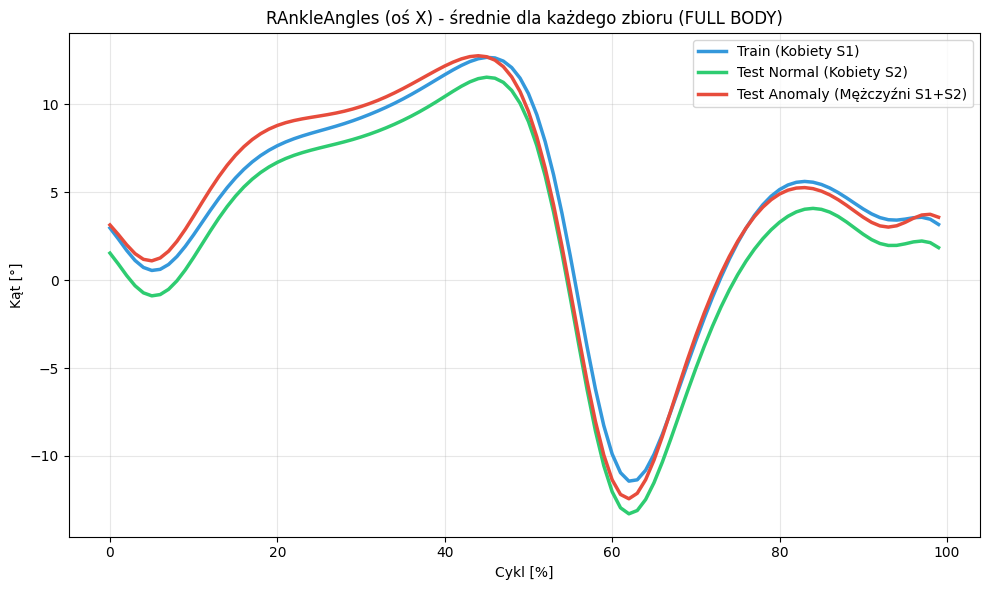


✅ DANE FULL BODY GOTOWE DO TRENINGU VAE!

💡 Strategia:
  1. Trenuj VAE na Kobietach S1 (80%)
  2. Waliduj na Kobietach S1 (20%)
  3. Testuj na:
     • Kobiety S2 (normal)
     • Mężczyźni wszyscy (anomaly)


In [54]:
from pathlib import Path
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

DATA_DIR = Path(r"E:/marcel.furs/Documents/Data_Run_Walk/Data_Run_Walk/EXPERIMENTS/exp1b_train_F_detect_M")

LATENT_DIM = 4         
WIDTH_FIRST = 128      
BETA_KL = 0.01          
BATCH_SIZE = 32         
DROPOUT = 0.2        
LEARNING_RATE = 1e-3    
EPOCHS = 1000           
PATIENCE = 30     

ANGLE_CHANNELS = [
    "LFootProgressAngles", "RFootProgressAngles",
    "LHipAngles",          "RHipAngles",
    "LKneeAngles",         "RKneeAngles",
    "LAnkleAngles",        "RAnkleAngles",
    "LForeFootAngles",     "RForeFootAngles",
    "LSpineAngles",        "RSpineAngles",
    "LShoulderAngles",     "RShoulderAngles",
    "LElbowAngles",        "RElbowAngles",
    "LWristAngles",        "RWristAngles",
    "LNeckAngles",         "RNeckAngles",
    "LPelvisAngles",       "RPelvisAngles",
    "LThoraxAngles",       "RThoraxAngles",
    "LHeadAngles",         "RHeadAngles",
]
NUM_JOINTS = len(ANGLE_CHANNELS)  # 26

X_train_final  = np.load(DATA_DIR / "X_train.npy")
X_val          = np.load(DATA_DIR / "X_val.npy")
X_test_normal  = np.load(DATA_DIR / "X_test_normal.npy")
X_test_anomaly = np.load(DATA_DIR / "X_test_anomaly.npy")

subjects_train = np.load(DATA_DIR / "subjects_train.npy", allow_pickle=True)
subjects_val   = np.load(DATA_DIR / "subjects_val.npy", allow_pickle=True)
subjects_test_normal  = np.load(DATA_DIR / "subjects_test_normal.npy", allow_pickle=True)
subjects_test_anomaly = np.load(DATA_DIR / "subjects_test_anomaly.npy", allow_pickle=True)

print(f"  TRAIN (Kobiety S1, 80%):        {X_train_final.shape} - {len(np.unique(subjects_train))} osób")
print(f"  VAL   (Kobiety S1, 20%):        {X_val.shape} - {len(np.unique(subjects_val))} osób")
print(f"  TEST Normal (Kobiety S2):       {X_test_normal.shape} - {len(np.unique(subjects_test_normal))} osób")
print(f"  TEST Anomaly (Mężczyźni S1+S2): {X_test_anomaly.shape} - {len(np.unique(subjects_test_anomaly))} osób")


# PREPROCESSING (Flatten + Z-score)
X_train_flat        = X_train_final.reshape(X_train_final.shape[0], -1)
X_val_flat          = X_val.reshape(X_val.shape[0], -1)
X_test_normal_flat  = X_test_normal.reshape(X_test_normal.shape[0], -1)
X_test_anomaly_flat = X_test_anomaly.reshape(X_test_anomaly.shape[0], -1)

print(f"  Train:        {X_train_flat.shape}")
print(f"  Val:          {X_val_flat.shape}")
print(f"  Test Normal:  {X_test_normal_flat.shape}")
print(f"  Test Anomaly: {X_test_anomaly_flat.shape}")

scaler = StandardScaler()
X_train_norm        = scaler.fit_transform(X_train_flat)
X_val_norm          = scaler.transform(X_val_flat)
X_test_normal_norm  = scaler.transform(X_test_normal_flat)
X_test_anomaly_norm = scaler.transform(X_test_anomaly_flat)

print(f"  Train:        mean={X_train_norm.mean():.3f}, std={X_train_norm.std():.3f}")
print(f"  Val:          mean={X_val_norm.mean():.3f}, std={X_val_norm.std():.3f}")
print(f"  Test Normal:  mean={X_test_normal_norm.mean():.3f}, std={X_test_normal_norm.std():.3f}")
print(f"  Test Anomaly: mean={X_test_anomaly_norm.mean():.3f}, std={X_test_anomaly_norm.std():.3f}")

input_dim = X_train_norm.shape[1]
print(f"\n Input dimension (FULL BODY): {input_dim}")

In [55]:
# SETUP

In [56]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K

In [57]:
# Create a sampling layer

In [58]:
class Sampling(layers.Layer):
    """Reparameterization trick: z = μ + ε·σ,  ε∼N(0,I)."""
    
    def call(self, inputs):
        z_mean, z_logvar = inputs
        epsilon = tf.random.normal(tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_logvar) * epsilon

In [59]:
# Build the encoder (

In [60]:
encoder_inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(WIDTH_FIRST, activation="relu")(encoder_inputs)
x = layers.Dropout(DROPOUT)(x)
x = layers.Dense(WIDTH_FIRST // 2, activation="relu")(x)
x = layers.Dropout(DROPOUT)(x)
z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

print("\nENCODER:")
encoder.summary()


ENCODER:


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)    │ (None, 7800)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_20 (Dense)              │ (None, 128)               │         998,528 │ input_layer_8[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_16 (Dropout)          │ (None, 128)               │               0 │ dense_20[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_21 (Dense)              │ (None, 64)                │           8,256 │ dropout_16[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_17 (Dropout)          │ (None, 64)                │               0 │ dense_21[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_mean (Dense)                │ (None, 4)                 │             260 │ dropout_17[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_log_var (Dense)             │ (None, 4)                 │             260 │ dropout_17[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sampling_4 (Sampling)         │ (None, 4)                 │               0 │ z_mean[0][0],              │
│                               │                           │                 │ z_log_var[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,007,304 (3.84 MB)

 Trainable params: 1,007,304 (3.84 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# Build the decoder

In [62]:
latent_input = keras.Input(shape=(LATENT_DIM,))
x = layers.Dense(WIDTH_FIRST // 2, activation="relu")(latent_input)
x = layers.Dropout(DROPOUT)(x)
x = layers.Dense(WIDTH_FIRST, activation="relu")(x)
x = layers.Dropout(DROPOUT)(x)
decoder_output = layers.Dense(input_dim, activation="linear")(x)
decoder = keras.Model(latent_input, decoder_output, name="decoder")

print("\nDecoder:")
decoder.summary()


Decoder:


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)           │ (None, 4)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 64)                  │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 7800)                │       1,006,200 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,014,840 (3.87 MB)

 Trainable params: 1,014,840 (3.87 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
# Define the VAE

In [64]:
"""β-VAE: loss = MSE + β·KL."""
class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=BETA_KL, **kw):
        super().__init__(**kw)
        self.encoder     = encoder
        self.decoder     = decoder
        self.beta        = beta
        self.loss_tracker= keras.metrics.Mean(name="loss")
        self.mse_tracker = keras.metrics.Mean(name="mse")
        self.kl_tracker  = keras.metrics.Mean(name="kl")

    @property
    def metrics(self):          # <– Keras będzie to resetował co epokę
        return [self.loss_tracker, self.mse_tracker, self.kl_tracker]

    def call(self, x):
        _, _, z = self.encoder(x)
        return self.decoder(z)

    def train_step(self, x):
        with tf.GradientTape() as tape:
            mu, logvar, z = self.encoder(x, training=True)
            logvar = tf.clip_by_value(logvar, -10.0, 10.0)       #BEZ TEGO
            recon = self.decoder(z, training=True)
            mse = tf.reduce_mean(tf.square(x - recon), axis=1)
            kl  = -0.5 * tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1)
            #loss = tf.reduce_mean(mse + self.beta * kl)
            loss = tf.reduce_mean(mse + self.beta * kl)

        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.loss_tracker.update_state(loss)
        self.mse_tracker.update_state(tf.reduce_mean(mse))
        self.kl_tracker.update_state(tf.reduce_mean(kl))

        return {
            "loss": self.loss_tracker.result(),
            "mse":  self.mse_tracker.result(),
            "kl":   self.kl_tracker.result()
        }

    # val step (żeby działał val_loss)
    def test_step(self, x):
        mu, logvar, z = self.encoder(x, training=False)
        logvar = tf.clip_by_value(logvar, -10.0, 10.0)
        recon  = self.decoder(z, training=False)
        mse    = tf.reduce_mean(tf.square(x - recon), axis=1)
        kl     = -0.5 * tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1)
        loss   = tf.reduce_mean(mse + self.beta * kl)
        self.loss_tracker.update_state(loss)
        self.mse_tracker.update_state(tf.reduce_mean(mse))
        self.kl_tracker.update_state(tf.reduce_mean(kl))
        return {
            "loss": self.loss_tracker.result(),
            "mse":  self.mse_tracker.result(),
            "kl":   self.kl_tracker.result()
        }




In [65]:
# Train the VAE


TRENING
Uruchamiam trening...
  Train (F S1 80%): 92 próbek
  Val (F S1 20%):   28 próbek
Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - kl: 49.4569 - loss: 1.5097 - mse: 1.0151 - val_kl: 4.0883 - val_loss: 1.1909 - val_mse: 1.1500
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - kl: 57.4432 - loss: 1.5984 - mse: 1.0239 - val_kl: 5.3031 - val_loss: 1.2024 - val_mse: 1.1494
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - kl: 94.7467 - loss: 1.9781 - mse: 1.0306 - val_kl: 25.0718 - val_loss: 1.4038 - val_mse: 1.1530
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - kl: 170.2359 - loss: 2.7328 - mse: 1.0305 - val_kl: 120.9451 - val_loss: 2.3779 - val_mse: 1.1684
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - kl: 65.7742 - loss: 1.6497 - mse: 0.9919 - val_kl: 78.1039 - val_loss: 1.9438 - val_mse: 1.1627
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - kl: 178.4464 - loss: 2.7685 - mse: 0.9840 - val_kl: 25.5297 - val_loss: 1.4189 - val_mse: 1.1636
Epoch 7/1000


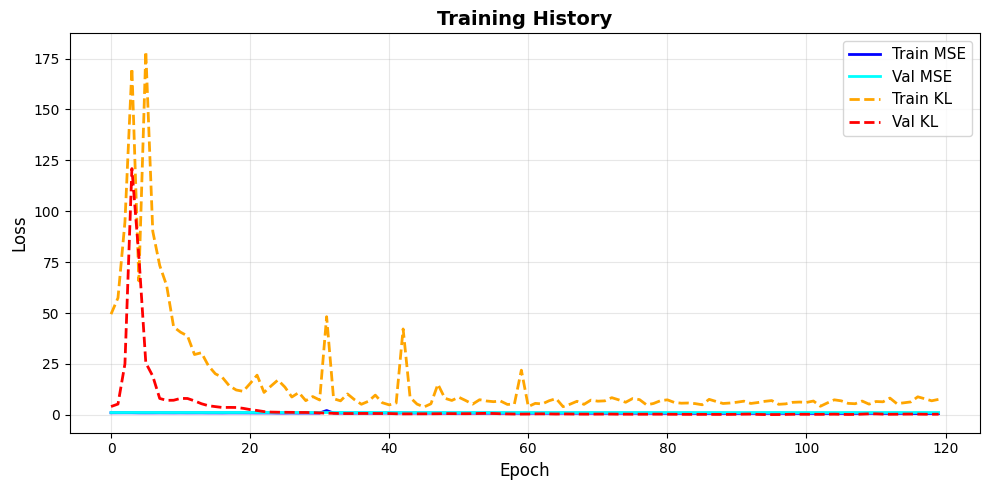

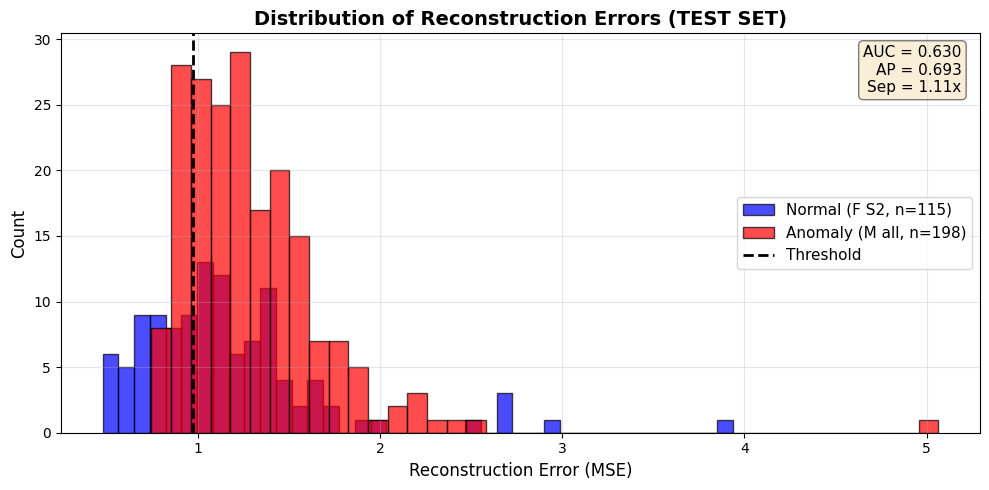

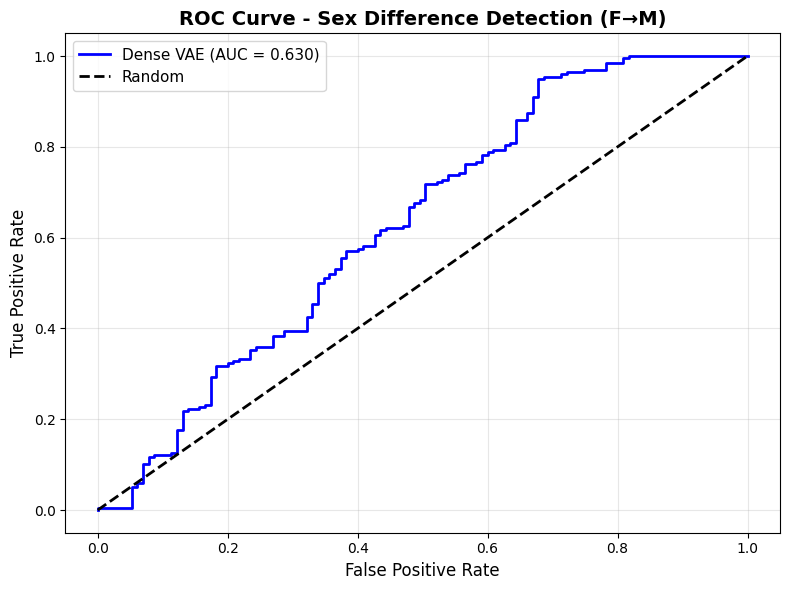

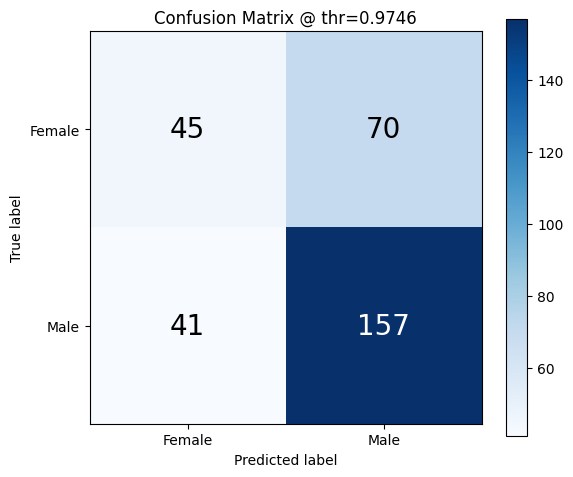

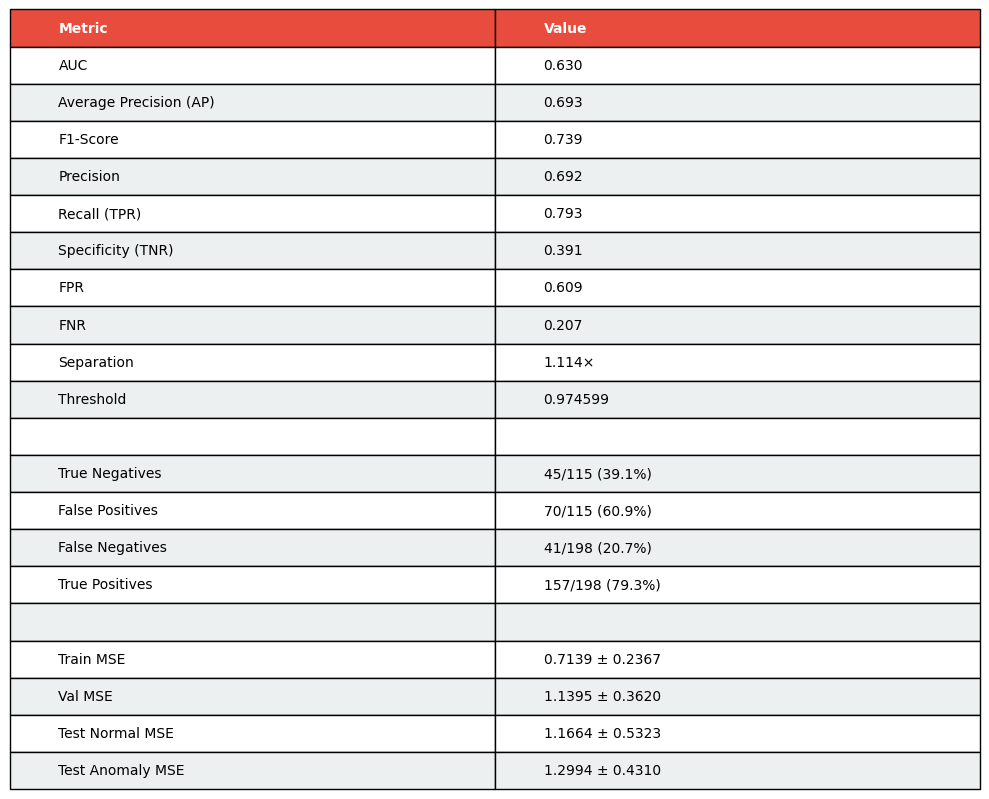


✅ GOTOWE!


In [66]:
vae = VAE(encoder, decoder, beta=BETA_KL)
vae.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE, clipnorm=1.0))

# 6. Train

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

history = vae.fit(
    X_train_norm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(X_val_norm, None),
    callbacks=[early_stop],
    verbose=1
)


def compute_mse(model, X):
    mu, logvar, z = model.encoder.predict(X, verbose=0)
    X_recon = model.decoder.predict(z, verbose=0)
    return np.mean((X - X_recon)**2, axis=1)

mse_train = compute_mse(vae, X_train_norm)                   # Train (F S1 80%)
mse_val = compute_mse(vae, X_val_norm)                       # Val (F S1 20%)
mse_test_normal = compute_mse(vae, X_test_normal_norm)       # Test Normal (F S2)
mse_test_anomaly = compute_mse(vae, X_test_anomaly_norm)     # Test Anomaly

print(f"  Train (F S1 80%):     {mse_train.mean():.6f} ± {mse_train.std():.6f}")
print(f"  Val (F S1 20%):       {mse_val.mean():.6f} ± {mse_val.std():.6f}")
print(f"  Test Normal (F S2):   {mse_test_normal.mean():.6f} ± {mse_test_normal.std():.6f}")
print(f"  Test Anomaly (M all): {mse_test_anomaly.mean():.6f} ± {mse_test_anomaly.std():.6f}")


y_train_val = np.concatenate([
    np.zeros(len(mse_train)),  # train = 0
    np.ones(len(mse_val))      # val = 1
])
mse_train_val = np.concatenate([mse_train, mse_val])

from sklearn.metrics import roc_curve, confusion_matrix

fpr_tv, tpr_tv, thresholds_tv = roc_curve(y_train_val, mse_train_val)


y_true = np.concatenate([
    np.zeros(len(mse_test_normal)),    # 0 = normal
    np.ones(len(mse_test_anomaly))     # 1 = anomaly
])
y_score = np.concatenate([mse_test_normal, mse_test_anomaly])

y_pred = (y_score > threshold).astype(int)


from sklearn.metrics import roc_auc_score, average_precision_score

auc = roc_auc_score(y_true, y_score)
ap = average_precision_score(y_true, y_score)
separation = mse_test_anomaly.mean() / mse_test_normal.mean()

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()


fpr, tpr, _ = roc_curve(y_true, y_score)


fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history["mse"], label="Train MSE", linewidth=2, color='blue')
ax.plot(history.history["val_mse"], label="Val MSE", linewidth=2, color='cyan')
ax.plot(history.history["kl"], label="Train KL", linewidth=2, linestyle='--', color='orange')
ax.plot(history.history["val_kl"], label="Val KL", linewidth=2, linestyle='--', color='red')
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Training History", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Histogram 
plt.figure(figsize=(10, 5))

plt.hist(mse_test_normal, bins=40, alpha=0.7, 
         label=f'Normal (F S2, n={len(mse_test_normal)})', 
         color='blue', edgecolor='black')
plt.hist(mse_test_anomaly, bins=40, alpha=0.7, 
         label=f'Anomaly (M all, n={len(mse_test_anomaly)})', 
         color='red', edgecolor='black')
plt.axvline(threshold, color='black', linestyle='--', linewidth=2, 
            label=f'Threshold')

plt.xlabel('Reconstruction Error (MSE)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Reconstruction Errors (TEST SET)', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

textstr = f'AUC = {auc:.3f}\nAP = {ap:.3f}\nSep = {separation:.2f}x'
plt.text(0.98, 0.97, textstr, transform=plt.gca().transAxes,
         fontsize=11, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, color='blue', label=f'Dense VAE (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Sex Difference Detection (F→M)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow([[tn, fp], [fn, tp]], interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=[0, 1], yticks=[0, 1],
       xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'],
       ylabel='True label', xlabel='Predicted label',
       title=f'Confusion Matrix @ thr={threshold:.4f}')
for i in range(2):
    for j in range(2):
        val = [[tn, fp], [fn, tp]][i][j]
        ax.text(j, i, val, ha="center", va="center",
                color="white" if val > (tn+tp)/2 else "black",
                fontsize=20)
plt.tight_layout()
plt.show()